In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
# Classifier models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

df = pd.read_csv("../Data/CO2 Emissions_Canada .csv")
# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Create classification target (Low, Medium, High emissions)
df['CO2_Class'] = pd.qcut(df['CO2 Emissions(g/km)'], q=3, labels=['Low', 'Medium', 'High'])

# Define features and target
X = df.drop(columns=["CO2 Emissions(g/km)", "CO2_Class"])
y = df["CO2_Class"]

# Encode the target variable y
le_y = LabelEncoder()
y = le_y.fit_transform(y)
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Initialize models
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
ada = AdaBoostClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

# Voting Classifier (ensemble of all three)
voting = VotingClassifier(estimators=[
    ('xgb', xgb),
    ('ada', ada),
    ('rf', rf)
], voting='soft')  # 'soft' averages predicted probabilities

models = {
    "XGBoost": xgb,
    "AdaBoost": ada,
    "Random Forest": rf,
    "Voting Classifier": voting
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)

    acc = accuracy_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred, average='weighted')
    rec = recall_score(y_train, y_pred, average='weighted')
    f1 = f1_score(y_train, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(f1, 3)
    })

# Show comparison table
results_df = pd.DataFrame(results)
print("\n Classifier Model Performance Comparison \n")
print(results_df.sort_values(by="F1 Score", ascending=False))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:10:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:10:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Classifier Model Performance Comparison 

               Model  Accuracy  Precision  Recall  F1 Score
0            XGBoost     0.997      0.997   0.997     0.997
2      Random Forest     0.997      0.997   0.997     0.997
3  Voting Classifier     0.997      0.997   0.997     0.997
1           AdaBoost     0.951      0.951   0.951     0.951


In [ ]:
test_results = []

for name, model in models.items():
    # Make predictions on the test set
    y_pred_test = model.predict(X_test)

    # Calculate metrics on the test set
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test, average='weighted')
    rec_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    test_results.append({
        "Model": name,
        "Accuracy": round(acc_test, 3),
        "Precision": round(prec_test, 3),
        "Recall": round(rec_test, 3),
        "F1 Score": round(f1_test, 3)
    })

# Show comparison table for test set performance
test_results_df = pd.DataFrame(test_results)
print("\n Classifier Model Performance Comparison on Test Set \n")
print(test_results_df.sort_values(by="F1 Score", ascending=False))


 Classifier Model Performance Comparison on Test Set 

               Model  Accuracy  Precision  Recall  F1 Score
0            XGBoost     0.981      0.981   0.981     0.981
3  Voting Classifier     0.978      0.978   0.978     0.978
2      Random Forest     0.977      0.977   0.977     0.977
1           AdaBoost     0.945      0.946   0.945     0.945


In [ ]:
import pandas as pd

# Define your manual data. Ensure column names match X_train.columns
# For categorical columns, use their encoded numerical values.
# Example values based on an arbitrary row from X_test to guide input:
# Make: 5 (e.g., 'BMW')
# Model: 1921 (e.g., 'X5')
# Vehicle Class: 11 (e.g., 'SUV - SMALL')
# Transmission: 3 (e.g., 'A8')
# Fuel Type: 4 (e.g., 'Z')
manual_data = {
    'Make': [5], # Example numerical encoding for a car manufacturer
    'Model': [1921], # Example numerical encoding for a specific model
    'Vehicle Class': [11], # Example numerical encoding for vehicle class
    'Engine Size(L)': [3.0],
    'Cylinders': [6],
    'Transmission': [3], # Example numerical encoding for transmission type
    'Fuel Type': [4], # Example numerical encoding for fuel type
    'Fuel Consumption City (L/100 km)': [12.0],
    'Fuel Consumption Hwy (L/100 km)': [8.3],
    'Fuel Consumption Comb (L/100 km)': [10.3],
    'Fuel Consumption Comb (mpg)': [27]
}

# Convert manual data to a DataFrame, ensuring column order matches X_train
manual_df = pd.DataFrame(manual_data, columns=X_train.columns)

# Use the best model (XGBoost) to predict
# best_model was previously defined as xgb
manual_prediction_encoded = best_model.predict(manual_df)

# Inverse transform the prediction to get the original class name
manual_prediction_label = le_y.inverse_transform(manual_prediction_encoded)

print(f"Predicted CO2 Class for the manual data: {manual_prediction_label[0]}")

Predicted CO2 Class for the manual data: Medium


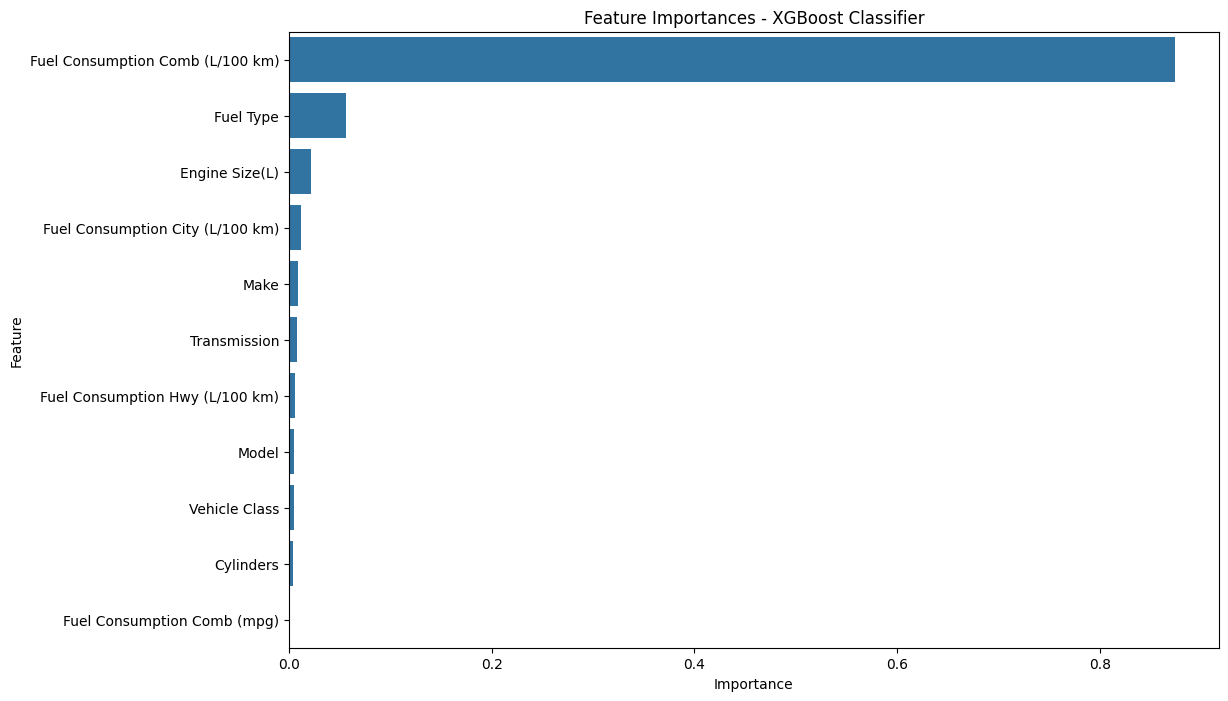

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model (XGBoost)
# The 'best_model' variable from the previous cell is already set to xgb
feature_importances = best_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances - XGBoost Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
# Inverse transform numerical labels back to original class names
y_test_labels = le_y.inverse_transform(y_test)
y_pred_best_labels = le_y.inverse_transform(y_pred_best)

# Create a DataFrame to analyze misclassifications
misclassification_analysis = X_test.copy()
misclassification_analysis['Actual_CO2_Class'] = y_test_labels
misclassification_analysis['Predicted_CO2_Class'] = y_pred_best_labels

# Filter for misclassified instances
misclassified_df = misclassification_analysis[misclassification_analysis['Actual_CO2_Class'] != misclassification_analysis['Predicted_CO2_Class']]

print(f"Total misclassified instances: {len(misclassified_df)}")

if not misclassified_df.empty:
    print("\nExamples of misclassified instances (first 10):\n")
    display(misclassified_df.head(10))

    print("\nDistribution of misclassifications by actual class:\n")
    display(misclassified_df['Actual_CO2_Class'].value_counts())

    print("\nDistribution of misclassifications by predicted class:\n")
    display(misclassified_df['Predicted_CO2_Class'].value_counts())
else:
    print("No misclassified instances found. The model achieved 100% accuracy on the test set.")

Total misclassified instances: 24

Examples of misclassified instances (first 10):



,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Actual_CO2_Class,Predicted_CO2_Class
5618,32,1271,11,3.0,6,9,4,12.9,10.2,11.7,24,Medium,High
4403,15,1648,6,4.3,6,3,3,13.4,10.0,11.8,24,High,Medium
2436,13,1790,7,1.6,4,15,3,10.8,8.0,9.5,30,Medium,Low
3295,9,783,11,2.4,4,3,3,11.0,7.5,9.4,30,Medium,Low
1904,39,444,2,3.5,6,15,3,11.0,7.7,9.5,30,Low,Medium
1601,21,1635,4,3.3,6,15,3,13.2,9.7,11.6,24,Medium,High
1488,16,504,0,2.4,4,25,4,10.8,7.6,9.4,30,Low,Medium
5133,14,943,0,3.3,6,17,4,13.3,9.5,11.6,24,High,Medium
1059,40,1786,12,3.0,6,17,0,11.8,8.1,10.2,28,High,Medium
1005,39,1760,5,2.7,4,24,3,12.8,10.6,11.8,24,Medium,High



Distribution of misclassifications by actual class:



,count
Actual_CO2_Class,
Medium,14
Low,6
High,4



Distribution of misclassifications by predicted class:



,count
Predicted_CO2_Class,
Medium,10
High,7
Low,7


In [ ]:
print("\n Top 3 Models - Test Set Performance Comparison \n")
print(test_results_df.sort_values(by="F1 Score", ascending=False).head(3))


 Top 3 Models - Test Set Performance Comparison 

               Model  Accuracy  Precision  Recall  F1 Score
0            XGBoost     0.981      0.981   0.981     0.981
3  Voting Classifier     0.978      0.978   0.978     0.978
2      Random Forest     0.977      0.977   0.977     0.977


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:10:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report for XGBoost Classifier:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       413
           1       0.98      0.99      0.98       421
           2       0.98      0.97      0.97       423

    accuracy                           0.98      1257
   macro avg       0.98      0.98      0.98      1257
weighted avg       0.98      0.98      0.98      1257



Text(0.5, 1.0, 'Confusion Matrix - XGBoost Classifier')

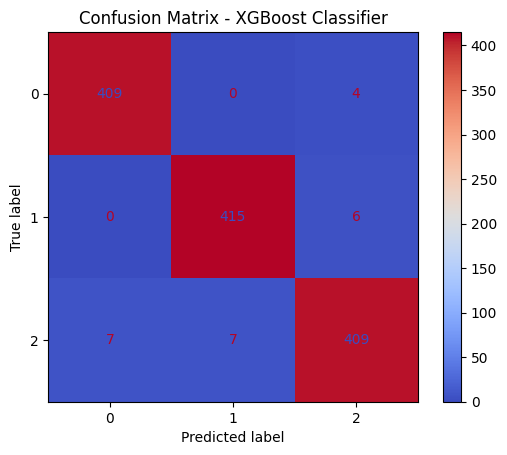

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = xgb
y_pred_best = best_model.fit(X_train, y_train).predict(X_test)

print("\nClassification Report for XGBoost Classifier:\n")
print(classification_report(y_test, y_pred_best))

# Confusion matrix visualization
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap="coolwarm")
plt.title("Confusion Matrix - XGBoost Classifier")
